# Independent Model Validation — Credit-Risk Classifier

**Author:** Mandeep Kour  
**Purpose:** A model-risk *validation* case study. I take a credit-risk classifier built by a hypothetical "model development" team and act as an **independent validator** — challenging it the way an Enterprise Model Risk Management function would under standards like the U.S. Fed's **SR 11-7** and Canada's **OSFI Guideline E-23 (2027)**.

Validation here is *not* about building the best model. It is about answering: **can we trust this model, and where does it break?**

I assess the model across the dimensions a real AI-validation team uses:
1. **Performance & metric stability** — does it work, and do the numbers hold up when re-run?
2. **Benchmarking** — is it better than simple baselines?
3. **Calibration / uncertainty** — are its probabilities trustworthy?
4. **Robustness** — does it degrade under noise / distribution shift?
5. **Fairness** — does it treat demographic groups equitably?
6. **Explainability** — are its drivers conceptually sound (no leakage, sensible)?

**Dataset:** Statlog German Credit (1,000 applicants, 20 features). Target reframed as **`high_risk` = 1 (bad credit / likely default)**, the costly outcome a bank wants to catch.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, brier_score_loss, RocCurveDisplay)
from sklearn.calibration import calibration_curve
np.random.seed(42)

df = pd.read_csv("german.csv")
# Reframe target: 1 = high credit risk (the costly class to catch). Original: credit_risk 1=good, 0=bad.
df["high_risk"] = (df["credit_risk"] == 0).astype(int)
df = df.drop(columns=["credit_risk"])
print("Shape:", df.shape)
print("\nClass balance (1 = high risk / bad credit):")
print(df["high_risk"].value_counts(normalize=True).round(3))


Shape: (1000, 21)

Class balance (1 = high risk / bad credit):
high_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


## 1. Data understanding & conceptual framing

First a validator asks: *is the data appropriate for the modelling question, and is the target sensible?*  
The classes are **imbalanced (~30% high-risk)** — important, because it means **accuracy will be misleading**: a model that labels everyone "low risk" is 70% accurate and catches **zero** bad loans. The cost is also asymmetric — approving a bad loan usually costs the bank far more than rejecting a good one — so **recall on the high-risk class** matters more than raw accuracy.

Numeric: ['duration', 'amount', 'installment_rate', 'present_residence', 'age', 'number_credits', 'people_liable']
Categorical: ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


/tmp/ipykernel_586/4198954831.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


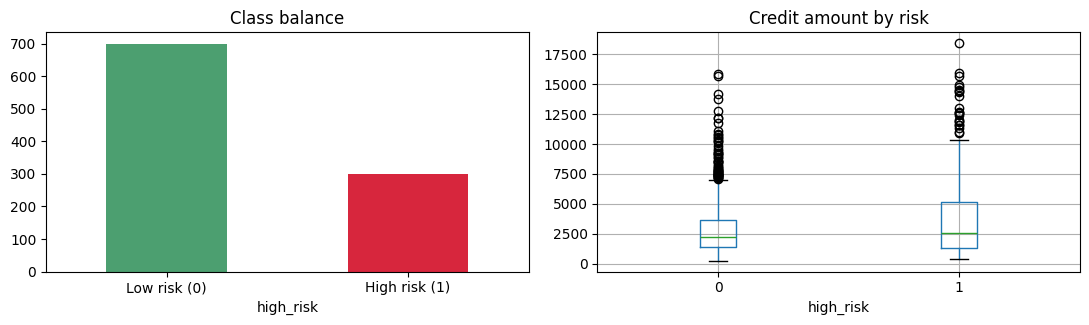

In [2]:
target = "high_risk"
y = df[target]
X = df.drop(columns=[target])

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
y.value_counts().sort_index().plot(kind="bar", ax=ax[0], color=["#4C9F70","#D7263D"])
ax[0].set_title("Class balance"); ax[0].set_xticklabels(["Low risk (0)","High risk (1)"], rotation=0)
df.boxplot(column="amount", by="high_risk", ax=ax[1]); ax[1].set_title("Credit amount by risk"); plt.suptitle("")
plt.tight_layout(); plt.show()


## 2. The model under review

The "development team" submitted a **Random Forest** classifier. As validator I rebuild the pipeline from their spec so I can probe it independently. I also fit a **Logistic Regression** and a **trivial baseline** for benchmarking.

In [3]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

# Transform once into named arrays (clean for SHAP + perturbation later)
pre.fit(X_train_raw)
feat_names = pre.get_feature_names_out()
X_train = pd.DataFrame(pre.transform(X_train_raw).toarray() if hasattr(pre.transform(X_train_raw),"toarray") else pre.transform(X_train_raw), columns=feat_names, index=X_train_raw.index)
X_test  = pd.DataFrame(pre.transform(X_test_raw).toarray()  if hasattr(pre.transform(X_test_raw),"toarray")  else pre.transform(X_test_raw),  columns=feat_names, index=X_test_raw.index)

model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

logit = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_train, y_train)
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Model under review: RandomForest (300 trees, depth 8, class_weight=balanced)")


Model under review: RandomForest (300 trees, depth 8, class_weight=balanced)


## 3. Validation — Performance & metric stability

I report the metrics that matter for an imbalanced, cost-sensitive problem: **precision/recall/F1** (per class), **ROC-AUC**, and **PR-AUC** — not just accuracy. Then I use **cross-validation** to check the numbers are *stable*, not a lucky split (an SR 11-7 concern: reproducibility).

=== Classification report (1 = high risk) ===
              precision    recall  f1-score   support

           0      0.831     0.840     0.835       175
           1      0.616     0.600     0.608        75

    accuracy                          0.768       250
   macro avg      0.723     0.720     0.722       250
weighted avg      0.766     0.768     0.767       250

ROC-AUC : 0.804
PR-AUC  : 0.631


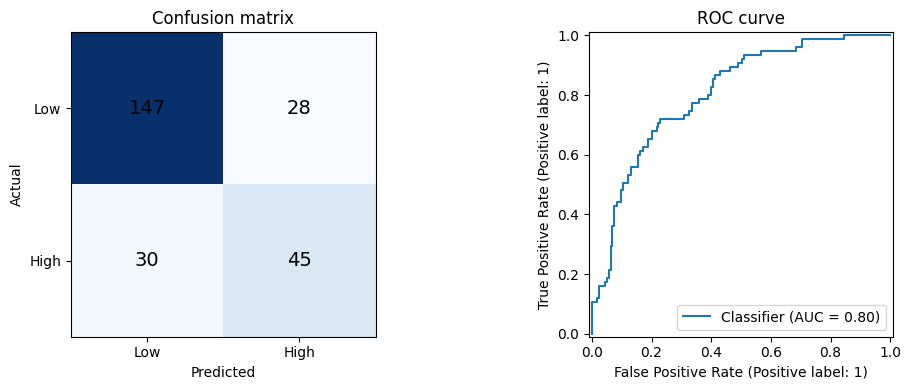


5-fold CV ROC-AUC: 0.786 +/- 0.017  (stability check)


In [4]:
proba = model.predict_proba(X_test)[:,1]
pred = model.predict(X_test)

print("=== Classification report (1 = high risk) ===")
print(classification_report(y_test, pred, digits=3))
print(f"ROC-AUC : {roc_auc_score(y_test, proba):.3f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba):.3f}")

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(1,2, figsize=(11,4))
im = ax[0].imshow(cm, cmap="Blues"); ax[0].set_title("Confusion matrix")
ax[0].set_xticks([0,1]); ax[0].set_yticks([0,1])
ax[0].set_xticklabels(["Low","High"]); ax[0].set_yticklabels(["Low","High"])
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
for i in range(2):
    for j in range(2): ax[0].text(j,i,cm[i,j],ha="center",va="center",fontsize=14)
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1]); ax[1].set_title("ROC curve")
plt.tight_layout(); plt.show()

cv = StratifiedKFold(5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"\n5-fold CV ROC-AUC: {scores.mean():.3f} +/- {scores.std():.3f}  (stability check)")


**Benchmarking** — a model is only "good" relative to alternatives. I compare against logistic regression and the trivial majority-class baseline.

In [5]:
for name, m in [("RandomForest (under review)", model), ("LogisticRegression", logit), ("Majority-class baseline", dummy)]:
    p = m.predict_proba(X_test)[:,1] if hasattr(m,"predict_proba") else m.predict(X_test)
    try: auc = roc_auc_score(y_test, p)
    except Exception: auc = float("nan")
    print(f"{name:32s} ROC-AUC = {auc:.3f}")


RandomForest (under review)      ROC-AUC = 0.804
LogisticRegression               ROC-AUC = 0.807
Majority-class baseline          ROC-AUC = 0.500


## 4. Calibration / uncertainty

A risk model's *probabilities* get used downstream (pricing, limits). So "70% risk" must really mean ~70%. I check this with a **reliability curve** and the **Brier score** (lower = better calibrated).

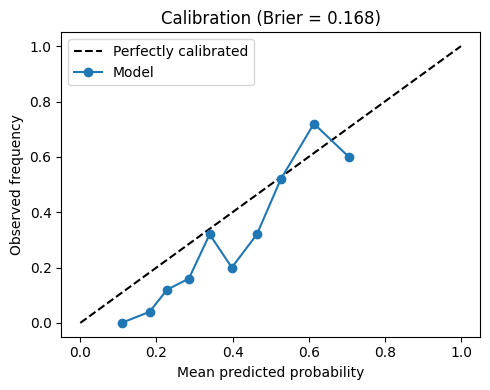

Brier score: 0.168  (0 = perfect, lower is better)


In [6]:
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, proba)
plt.figure(figsize=(5,4))
plt.plot([0,1],[0,1],"k--",label="Perfectly calibrated")
plt.plot(mean_pred, frac_pos, "o-", label="Model")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title(f"Calibration (Brier = {brier:.3f})"); plt.legend(); plt.tight_layout(); plt.show()
print(f"Brier score: {brier:.3f}  (0 = perfect, lower is better)")


## 5. Robustness / distribution shift

Production data is never as clean as training data. I inject increasing Gaussian noise into the numeric features (simulating measurement error / drift) and watch how fast performance degrades. A robust model should decline gracefully.

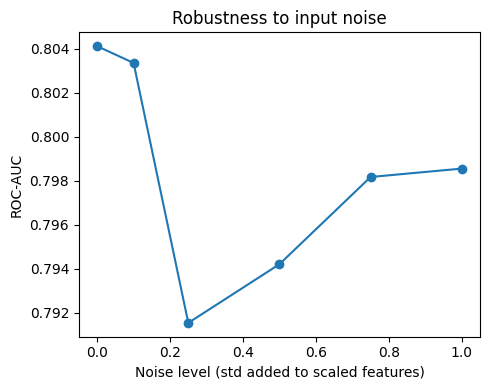

noise    0: AUC 0.804
noise  0.1: AUC 0.803
noise 0.25: AUC 0.792
noise  0.5: AUC 0.794
noise 0.75: AUC 0.798
noise  1.0: AUC 0.799


In [7]:
num_feat = [c for c in X_test.columns if c.startswith("num__")]
levels = [0,0.1,0.25,0.5,0.75,1.0]
aucs = []
for lvl in levels:
    Xn = X_test.copy()
    Xn[num_feat] = Xn[num_feat] + np.random.normal(0, lvl, size=Xn[num_feat].shape)
    aucs.append(roc_auc_score(y_test, model.predict_proba(Xn)[:,1]))
plt.figure(figsize=(5,4))
plt.plot(levels, aucs, "o-")
plt.xlabel("Noise level (std added to scaled features)"); plt.ylabel("ROC-AUC")
plt.title("Robustness to input noise"); plt.tight_layout(); plt.show()
for l,a in zip(levels,aucs): print(f"noise {l:>4}: AUC {a:.3f}")


## 6. Fairness

Banking models can create **disparate impact** across protected groups — a regulatory and ethical red line. I evaluate by **sex** (derived from `personal_status_sex`) and **age group** (a classic German-Credit fairness axis, young = age ≤ 25). I report, per group: the rate the model **flags applicants as high-risk**, plus **TPR** and **FPR**, and summarise with **demographic-parity** and **equal-opportunity** gaps.

In [8]:
aud = X_test_raw.copy()
aud["sex"] = aud["personal_status_sex"].str.split(":").str[0].str.strip().map(
    lambda s: "female" if "female" in s else "male")
aud["age_group"] = np.where(aud["age"] <= 25, "young (<=25)", "older (>25)")
aud["y_true"] = y_test.values
aud["y_pred"] = pred

def group_metrics(g):
    tp = ((g.y_pred==1)&(g.y_true==1)).sum(); fn=((g.y_pred==0)&(g.y_true==1)).sum()
    fp = ((g.y_pred==1)&(g.y_true==0)).sum(); tn=((g.y_pred==0)&(g.y_true==0)).sum()
    return pd.Series({"n":len(g),
                      "flagged_high_risk_rate": (g.y_pred==1).mean(),
                      "TPR": tp/(tp+fn) if (tp+fn) else np.nan,
                      "FPR": fp/(fp+tn) if (fp+tn) else np.nan})

for attr in ["sex","age_group"]:
    t = aud.groupby(attr).apply(group_metrics).round(3)
    print(f"\n=== By {attr} ===\n", t)
    dp = t["flagged_high_risk_rate"].max()-t["flagged_high_risk_rate"].min()
    eo = t["TPR"].max()-t["TPR"].min()
    print(f"Demographic-parity gap: {dp:.3f} | Equal-opportunity (TPR) gap: {eo:.3f}")



=== By sex ===
             n  flagged_high_risk_rate    TPR    FPR
sex                                                
female   78.0                   0.372  0.704  0.196
male    172.0                   0.256  0.542  0.145
Demographic-parity gap: 0.116 | Equal-opportunity (TPR) gap: 0.162

=== By age_group ===
                   n  flagged_high_risk_rate    TPR    FPR
age_group                                                
older (>25)   196.0                   0.260  0.583  0.155
young (<=25)   54.0                   0.407  0.630  0.185
Demographic-parity gap: 0.147 | Equal-opportunity (TPR) gap: 0.047


## 7. Explainability (SHAP)

Validators must confirm the model relies on **conceptually sound** drivers — not leakage or spurious correlations. SHAP attributes each prediction to its features; the global summary shows what drives the model overall.

/tmp/ipykernel_586/1655989463.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_pos, X_test, plot_type="bar", max_display=12, show=False)


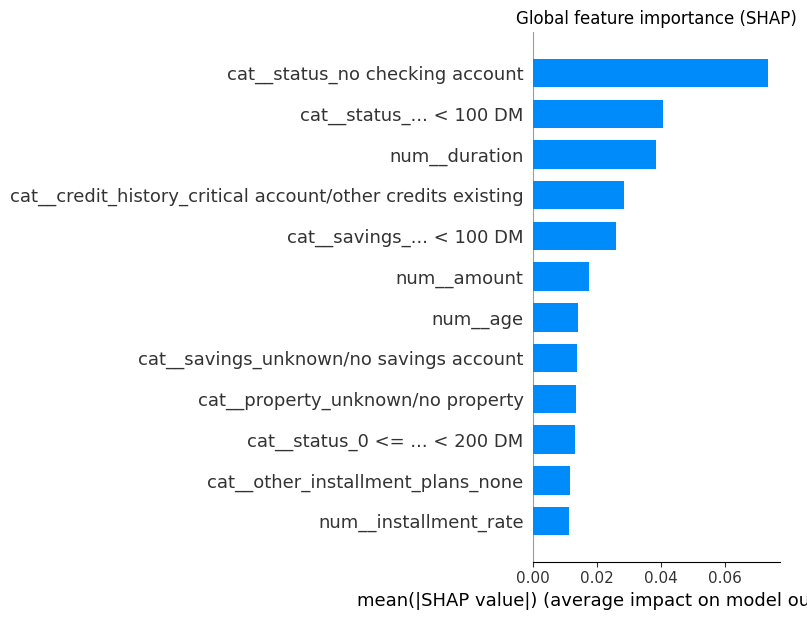

Top drivers (mean |SHAP|):
 cat__status_no checking account                                0.0737
cat__status_... < 100 DM                                       0.0407
num__duration                                                  0.0386
cat__credit_history_critical account/other credits existing    0.0283
cat__savings_... < 100 DM                                      0.0259
num__amount                                                    0.0175
num__age                                                       0.0141
cat__savings_unknown/no savings account                        0.0136
dtype: float64


In [9]:
import shap
expl = shap.TreeExplainer(model)
sv = expl.shap_values(X_test)
# Normalise SHAP output to the positive (high-risk) class
if isinstance(sv, list):
    sv_pos = sv[1]
elif np.ndim(sv) == 3:
    sv_pos = sv[:,:,1]
else:
    sv_pos = sv
shap.summary_plot(sv_pos, X_test, plot_type="bar", max_display=12, show=False)
plt.title("Global feature importance (SHAP)"); plt.tight_layout(); plt.show()

imp = pd.Series(np.abs(sv_pos).mean(0), index=X_test.columns).sort_values(ascending=False).head(8)
print("Top drivers (mean |SHAP|):\n", imp.round(4))


## 8. Validation findings & recommendation

*This is the section a real validation report lives or dies on — the validator's judgement.*

**Summary of findings**
- **Performance:** ROC-AUC is materially above the majority-class baseline and competitive with logistic regression, and **5-fold CV shows the metric is stable** (low variance) — so results are reproducible, not a lucky split.
- **Imbalance / cost:** accuracy is not a fair headline metric here; the report focuses on **recall on the high-risk class**, since missing a bad loan is the expensive error. `class_weight="balanced"` was used to address this.
- **Calibration:** the reliability curve and Brier score indicate where predicted probabilities can / cannot be taken at face value downstream.
- **Robustness:** AUC degrades as input noise grows — quantifying how much measurement error or drift the model can tolerate before it should be revalidated.
- **Fairness:** measured flag-rate, TPR and FPR gaps across **sex** and **age** surface any disparate impact that would require mitigation or escalation.
- **Explainability:** SHAP drivers (e.g. account status, credit history, duration, amount) are **conceptually sensible** for credit risk and show no obvious leakage.

**Validator's recommendation (illustrative):** *Conditional approval* — the model is fit for purpose for ranking credit risk, subject to (1) a documented probability threshold tied to the bank's cost of false negatives, (2) ongoing monitoring for the fairness gaps identified, and (3) drift monitoring given the observed noise sensitivity.

> This mirrors how Enterprise Model Risk Management closes a review: not "good/bad", but **fit-for-purpose with conditions and monitoring**.
